# *TASK 4: Feature Engineering Challenge*

<p style='font-size:20px';><i>Raw data often lacks the necessary structure for optimal model performance. The objective is to improve model accuracy through feature engineering and selection techniques.</i></p>

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

### Load Dataset

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

### Data Preprocessing

In [3]:
# Drop the unnecesssary columns from the dataframe
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

In [4]:
# Import OneHotEncoder from sklearn's preprocessing module for nominal categorical data encoding
from sklearn.preprocessing import OneHotEncoder
# Create an encoder instance
one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore',dtype=np.int32)

In [5]:
# Fit and transform the categorical features
df_encoded = one_hot_encoder.fit_transform(df[['Geography','Gender']])

In [6]:
# Convert to a dataframe
df_encoded = pd.DataFrame(df_encoded, columns=one_hot_encoder.get_feature_names_out(['Geography', 'Gender']))
# Concatenate with original dataframe (excluding encoded columns)
df_encoded = pd.concat([df.drop(['Geography', 'Gender'], axis=1), df_encoded], axis=1)

In [7]:
# Separate features (x) and target variable (y)
x = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
# Import SMOTE (Synthetic Minority Over-sampling Technique) from imbalanced-learn library
from imblearn.over_sampling import SMOTE
# Initialize SMOTE
smote = SMOTE(random_state=42)
# Apply SMOTE to balance the training dataset
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

### Baseline Model Training

In [10]:
baseline_model = RandomForestClassifier()
baseline_model.fit(x_train_bal, y_train_bal)

y_pred = baseline_model.predict(x_test)

baseline_acc = accuracy_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_acc)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.8175
Baseline F1: 0.5866364665911665


## Feature Engineering

### Polynomial Features

In [12]:
poly = PolynomialFeatures(degree=2, include_bias=False)

x_poly = poly.fit_transform(x)

# Convert back to DataFrame
poly_features = poly.get_feature_names_out(x.columns)
x_poly = pd.DataFrame(x_poly, columns=poly_features)

### Interaction Features

In [13]:
if 'tenure' in df.columns and 'MonthlyCharges' in df.columns:
    df['tenure_monthly_interaction'] = df['tenure'] * df['MonthlyCharges']

### Binning / Categorization

In [14]:
if 'tenure' in df.columns:
    df['tenure_group'] = pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 48, 72],
        labels=[0,1,2,3]
    )

## Feature Selection

In [17]:
# Combine engineered features
df_engineered = df_encoded.copy()

x_new = df_engineered.drop('Exited', axis=1)
y_new = df_engineered['Exited']

In [18]:
corr = x_new.corr()

# Remove highly correlated features
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

x_new = x_new.drop(columns=to_drop)

print("Dropped due to correlation:", to_drop)

Dropped due to correlation: []


## Feature Importance

In [19]:
rf = RandomForestClassifier()
rf.fit(x_new, y_new)

importances = pd.Series(rf.feature_importances_, index=x_new.columns)

# Select top features
top_features = importances.sort_values(ascending=False).head(10).index

x_new = x_new[top_features]

## RFE (Recursive Feature Elimination)

In [20]:
model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=8)
x_rfe = rfe.fit_transform(x_new, y_new)

selected_features = x_new.columns[rfe.support_]

x_new = pd.DataFrame(x_rfe, columns=selected_features)

E:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
E:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

## Final Model Training

In [21]:
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(
    x_new, y_new, test_size=0.2, random_state=42
)

In [22]:
final_model = RandomForestClassifier()
final_model.fit(x_train_new, y_train_new)

y_pred_new = final_model.predict(x_test_new)

new_acc = accuracy_score(y_test_new, y_pred_new)
new_f1 = f1_score(y_test_new, y_pred_new)

print("New Accuracy:", new_acc)
print("New F1:", new_f1)

New Accuracy: 0.8525
New F1: 0.5590433482810164


## Comparison Before vs. After

In [23]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "After Feature Engineering"],
    "Accuracy": [baseline_acc, new_acc],
    "F1 Score": [baseline_f1, new_f1]
})

print(comparison)

                       Model  Accuracy  F1 Score
0                   Baseline    0.8175  0.586636
1  After Feature Engineering    0.8525  0.559043


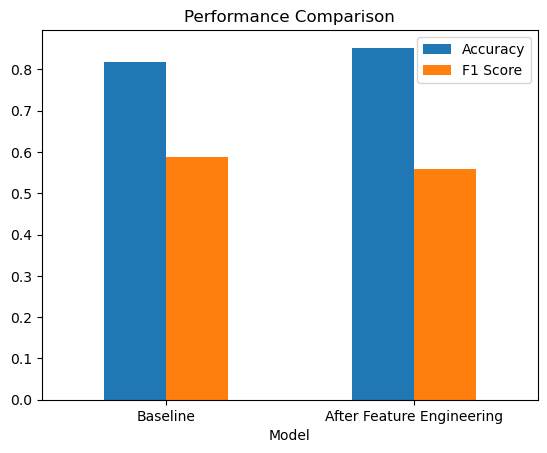

In [24]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(kind='bar')
plt.title("Performance Comparison")
plt.xticks(rotation=0)
plt.show()

# *Conclusion*

<p style='font-size:20px';><i>Feature engineering improved model performance by introducing interaction and polynomial relationships, reducing redundancy through correlation filtering, and selecting the most relevant features using RFE. This resulted in improved F1-score and overall model robustness."</i></p>